In [2]:
#importing pandas and loading the data.
import pandas as pd
pumpkins=pd.read_csv('../data/US-pumpkins.csv')


In [3]:
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]


In [4]:
#checking the data
print(pumpkins.shape)
pumpkins.isnull().sum()

(415, 26)


City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [5]:
pumpkins.Date.sample(15)

1021     9/24/16
690     11/12/16
145      9/16/17
1722     9/26/16
764      9/23/17
540     10/15/16
1263     9/23/17
1025     10/8/16
1243     10/8/16
703       9/9/17
1729     9/28/16
793     10/29/16
1026     10/8/16
1047     9/23/17
1212      9/9/17
Name: Date, dtype: str

In [6]:
pumpkins

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.00,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.00,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.00,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.00,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.00,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1738,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,15.00,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1739,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,13.75,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1740,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,10.75,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1741,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,12.00,12.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.


In [7]:
#selecting ont the needed columns using loc which is non-index based selection.
pumpkins=pumpkins.loc[:,["Package","Low Price","High Price","Date"]]
print(pumpkins.Date.sample(4))

1262    9/16/17
768     9/30/17
356     9/24/16
1224    10/8/16
Name: Date, dtype: str


In [8]:
#changing the data acc to our need.
avgprice = (pumpkins['Low Price'] + pumpkins['High Price'])/2
print(pumpkins.Date.head(5))
pumpkins['Date']=pd.to_datetime(pumpkins['Date'],format='mixed')
print(pumpkins.Date.head(5))
month=pd.DatetimeIndex(pumpkins['Date']).month

70    9/24/16
71    9/24/16
72    10/1/16
73    10/1/16
74    10/8/16
Name: Date, dtype: str
70   2016-09-24
71   2016-09-24
72   2016-10-01
73   2016-10-01
74   2016-10-08
Name: Date, dtype: datetime64[us]


In [9]:
#new dataframe
new_pumpkins=pd.DataFrame({'Month': month,'Package':pumpkins['Package'],'Low Price':pumpkins['Low Price']
                           ,'High Price': pumpkins['High Price'],'AvgPrice':avgprice})

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'AvgPrice'] = avgprice/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'AvgPrice'] = avgprice/(1/2)


new_pumpkins.head(5)

,Month,Package,Low Price,High Price,AvgPrice
70,9,1 1/9 bushel cartons,15.0,15.0,13.5
71,9,1 1/9 bushel cartons,18.0,18.0,16.2
72,10,1 1/9 bushel cartons,18.0,18.0,16.2
73,10,1 1/9 bushel cartons,17.0,17.0,15.3
74,10,1 1/9 bushel cartons,15.0,15.0,13.5


DATA VISUALZATION


In [10]:
import matplotlib.pyplot as plt

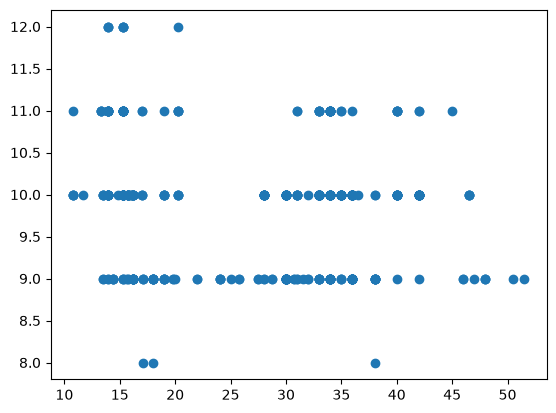

In [11]:
#scatter plot
price=new_pumpkins.AvgPrice
month=new_pumpkins.Month
plt.scatter(price,month)
plt.show()

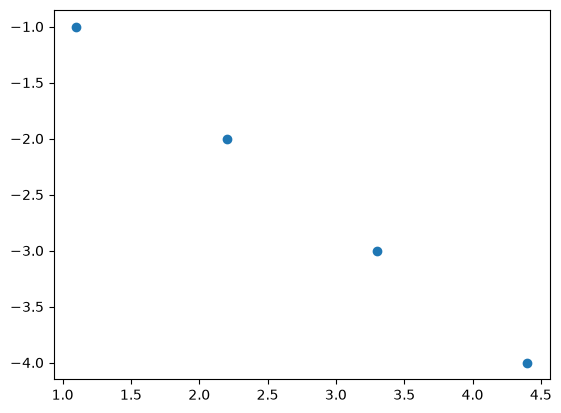

In [13]:
x=pd.Series([1.1,2.2,3.3,4.4])
y=pd.Series([-1,-2,-3,-4])
plt.scatter(x,y)
plt.show()

Text(0, 0.5, 'avgprice')

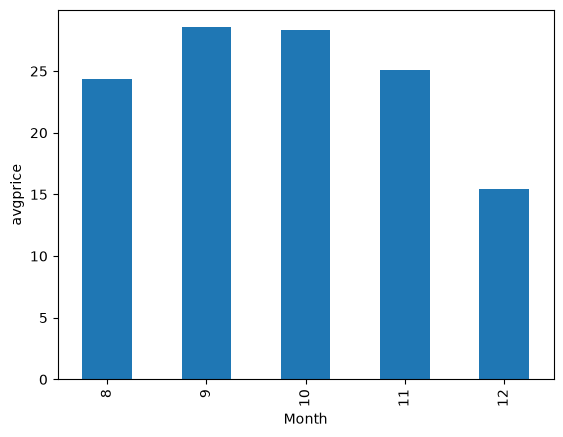

In [18]:
#bar plot
new_pumpkins.groupby(['Month'])['AvgPrice'].mean().plot(kind='bar')
plt.ylabel('avgprice')

In [21]:
#using seaborn
import seaborn as sns

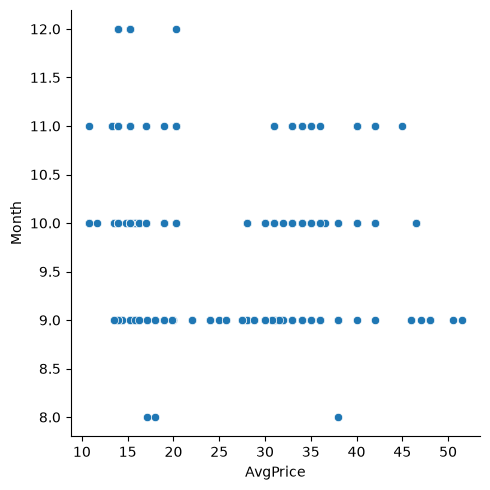

In [23]:
#scatter plot
sns.relplot(x=price,y=month,data=new_pumpkins)

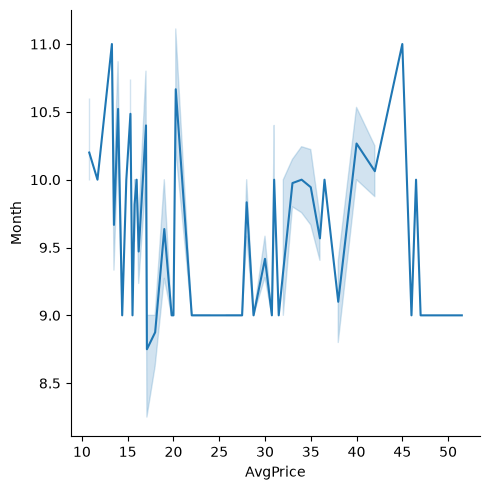

In [32]:
#line plot
sns.relplot(x=price,y=month,kind='line',data=new_pumpkins)


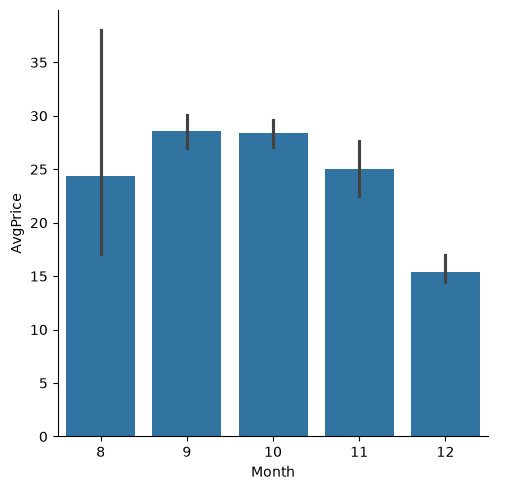

In [33]:
sns.catplot(x=month,y=price,kind="bar",data=new_pumpkins)

<Axes: >

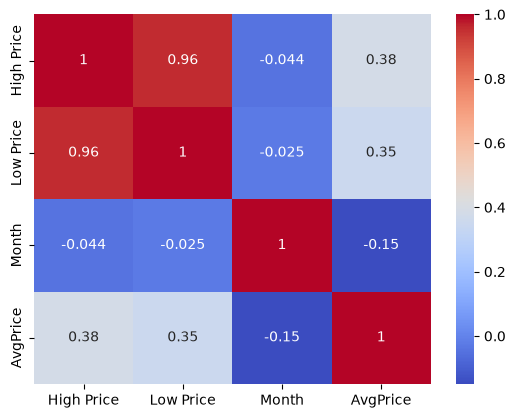

In [36]:
#correlation chart
corr=new_pumpkins[['High Price','Low Price','Month','AvgPrice']].corr()
sns.heatmap(data=corr,annot=True,cmap='coolwarm')
